In [91]:
!pip install xarray netCDF4
! pip install matplotlib seaborn

In [92]:
import sys
!{sys.executable} -m pip install scikit-learn

In [3]:
!{sys.executable} -m pip install -r requirements.txt

  Using cached accelerate-1.10.1-py3-none-any.whl.metadata (19 kB)
  Using cached aiofiles-25.1.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiohttp-3.10.11-cp310-cp310-macosx_11_0_arm64.whl.metadata (7.7 kB)
  Using cached aiohttp_retry-2.8.3-py3-none-any.whl.metadata (8.9 kB)
  Using cached aioice-0.10.1-py3-none-any.whl.metadata (4.1 kB)
  Using cached aiortc-1.14.0-py3-none-any.whl.metadata (4.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached aiosqlite-0.21.0-py3-none-any.whl.metadata (4.3 kB)
  Using cached albucore-0.0.33-py3-none-any.whl.metadata (7.8 kB)
  Using cached albumentationsx-2.0.11-py3-none-any.whl.metadata (79 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached anthropic-0.49.0-py3-none-any.whl.metadata (24 kB)
  Using cached anyio-4.11.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached anywidget-0.9.18-py3-none-a

In [4]:
import xarray as xr

file_path = "data/2000s/rasterfiles/Europe/2000/CN_Europe_0.25x0.25deg_BC_2000-06-01_2000-07-01.nc"

ds = xr.open_dataset(file_path)

print(ds)


<xarray.Dataset> Size: 5MB
Dimensions:      (lon: 268, lat: 141, time: 31)
Coordinates:
  * lon          (lon) float32 1kB -26.0 -25.75 -25.5 -25.25 ... 40.5 40.75 41.0
  * lat          (lat) float32 564B 35.8 36.05 36.3 36.55 ... 70.5 70.75 71.0
  * time         (time) datetime64[ns] 248B 2000-06-01 2000-06-02 ... 2000-07-01
Data variables:
    coefficient  (time, lat, lon) float32 5MB ...
    spatial_ref  int32 4B ...


In [ ]:
print(ds.time)

<xarray.DataArray 'time' (time: 31)> Size: 248B
array(['2000-06-01T00:00:00.000000000', '2000-06-02T00:00:00.000000000',
       '2000-06-03T00:00:00.000000000', '2000-06-04T00:00:00.000000000',
       '2000-06-05T00:00:00.000000000', '2000-06-06T00:00:00.000000000',
       '2000-06-07T00:00:00.000000000', '2000-06-08T00:00:00.000000000',
       '2000-06-09T00:00:00.000000000', '2000-06-10T00:00:00.000000000',
       '2000-06-11T00:00:00.000000000', '2000-06-12T00:00:00.000000000',
       '2000-06-13T00:00:00.000000000', '2000-06-14T00:00:00.000000000',
       '2000-06-15T00:00:00.000000000', '2000-06-16T00:00:00.000000000',
       '2000-06-17T00:00:00.000000000', '2000-06-18T00:00:00.000000000',
       '2000-06-19T00:00:00.000000000', '2000-06-20T00:00:00.000000000',
       '2000-06-21T00:00:00.000000000', '2000-06-22T00:00:00.000000000',
       '2000-06-23T00:00:00.000000000', '2000-06-24T00:00:00.000000000',
       '2000-06-25T00:00:00.000000000', '2000-06-26T00:00:00.000000000',
   

### some notes for better understanding 
longitude - east-west (Western Atlantic - Eastern Europe)
latitude - north-south (Mediterranean - Scandinavia)
time - number of days


There is a Complex Netwrok (CN) for each pixel and day

high value → heatwave propagation corridor
low value → not part of propagation pathway

## Extract data - exclude the first day of the next month

In [6]:
import xarray as xr
import numpy as np
import re
from pathlib import Path

COEFFS = ["DC", "CC", "BC", "ID", "OD"]
MONTHS = [6, 7, 8]  # JJA

def parse_year_month_from_filename(fname: str):
    """
    Extracts YYYY and MM from a filename containing '_YYYY-MM-01_'.
    Example: CN_Europe_0.25x0.25deg_BC_1991-06-01_1991-07-01.nc
    """
    m = re.search(r'_(\d{4})-(\d{2})-01_', fname)
    if not m:
        raise ValueError(f"Cannot parse year-month from filename: {fname}")
    return int(m.group(1)), int(m.group(2))

def open_cn_month_file(path: Path, var="coefficient") -> xr.DataArray:
    """
    Opens a monthly CN file, drops duplicate days, and trims to the intended month
    (so June file won't include July 1).
    """
    ds = xr.open_dataset(path)
    ds = ds.drop_duplicates(dim="time")
    year, month = parse_year_month_from_filename(path.name)
    ds = ds.sel(time=(ds.time.dt.year == year) & (ds.time.dt.month == month))
    return ds[var]

def load_coeff_over_years(root_dir: str, coeff: str, var="coefficient") -> xr.DataArray:
    """
    root_dir/
      1990/
        ..._DC_..._1990-06-01_1990-07-01.nc
        ..._DC_..._1990-07-01_1990-08-01.nc
        ..._DC_..._1990-08-01_1990-09-01.nc
        ..._CC_...
        ...
      1991/
      ...
    """
    root = Path(root_dir)
    arrays = []

    year_dirs = sorted([p for p in root.iterdir() if p.is_dir() and p.name.isdigit()],
                       key=lambda p: int(p.name))

    for yd in year_dirs:
        # grab all monthly files for this coeff in this year folder
        files = sorted(yd.glob(f"*_{coeff}_*.nc"))
        if len(files) == 0:
            continue

        for f in files:
            # trim to month from filename
            y, m = parse_year_month_from_filename(f.name)
            if m in MONTHS:
                arrays.append(open_cn_month_file(f, var=var))

    if not arrays:
        raise ValueError(f"No files found for coeff={coeff} in {root_dir}")

    da = xr.concat(arrays, dim="time").sortby("time").drop_duplicates(dim="time")
    return da

In [7]:
import glob

def load_cn_coefficient(file_glob: str, var_name="coefficient"):
    paths = sorted(glob.glob(file_glob))
    arrays = [open_cn_month_file(p, var_name=var_name) for p in paths]
    da = xr.concat(arrays, dim="time").sortby("time")
    da = da.drop_duplicates(dim="time")
    return da

## Load all the coefficients 

In [8]:
# bc = load_cn_coefficient("data/2000s/rasterfiles/Europe/2000/CN_Europe_0.25x0.25deg_BC_2000-06-01_2000-07-01.nc")
# dc = load_cn_coefficient("data/2000s/rasterfiles/Europe/2000/CN_Europe_0.25x0.25deg_DC_2000-06-01_2000-07-01.nc")
# cc = load_cn_coefficient("data/2000s/rasterfiles/Europe/2000/CN_Europe_0.25x0.25deg_CC_2000-06-01_2000-07-01.nc")


root_cn = "data/2000s/rasterfiles/Europe"  # contains year folders

dc  = load_coeff_over_years(root_cn, "DC")
cc  = load_coeff_over_years(root_cn, "CC")
bc  = load_coeff_over_years(root_cn, "BC")
idc = load_coeff_over_years(root_cn, "ID")
odc = load_coeff_over_years(root_cn, "OD")

In [9]:
import numpy as np

def quick_check(name, da):
    print(f"\n{name}")
    print(" dims:", da.dims, " shape:", da.shape)
    print(" time:", str(da.time.values[0]), "→", str(da.time.values[-1]))
    print(" dtype:", da.dtype)
    print(" min/max:", float(da.min()), float(da.max()))
    # quick NaN check on a small chunk
    chunk = da.isel(time=slice(0, 3)).values
    print(" NaNs in first 3 days:", bool(np.isnan(chunk).any()))

for name, da in [("DC", dc), ("CC", cc), ("BC", bc), ("ID", idc), ("OD", odc)]:
    quick_check(name, da)


DC
 dims: ('time', 'lat', 'lon')  shape: (920, 141, 268)
 time: 2000-06-01T00:00:00.000000000 → 2009-08-31T00:00:00.000000000
 dtype: float32
 min/max: -inf inf
 NaNs in first 3 days: False

CC
 dims: ('time', 'lat', 'lon')  shape: (920, 141, 268)
 time: 2000-06-01T00:00:00.000000000 → 2009-08-31T00:00:00.000000000
 dtype: float32
 min/max: -inf inf
 NaNs in first 3 days: False

BC
 dims: ('time', 'lat', 'lon')  shape: (920, 141, 268)
 time: 2000-06-01T00:00:00.000000000 → 2009-08-31T00:00:00.000000000
 dtype: float32
 min/max: -inf inf
 NaNs in first 3 days: True

ID
 dims: ('time', 'lat', 'lon')  shape: (920, 141, 268)
 time: 2000-06-01T00:00:00.000000000 → 2009-08-31T00:00:00.000000000
 dtype: float32
 min/max: -inf inf
 NaNs in first 3 days: False

OD
 dims: ('time', 'lat', 'lon')  shape: (920, 141, 268)
 time: 2000-06-01T00:00:00.000000000 → 2009-08-31T00:00:00.000000000
 dtype: float32
 min/max: -inf inf
 NaNs in first 3 days: False


In [10]:
import numpy as np

def finiteness_report(name, da):
    finite = np.isfinite(da.values)
    frac_bad = 1.0 - finite.mean()
    print(f"{name}: bad fraction={frac_bad:.6f} | "
          f"nan={np.isnan(da.values).any()} | inf={np.isinf(da.values).any()}")

for name, da in [("DC", dc), ("CC", cc), ("BC", bc), ("ID", idc), ("OD", odc)]:
    finiteness_report(name, da)

DC: bad fraction=0.001028 | nan=True | inf=True
CC: bad fraction=0.001326 | nan=True | inf=True
BC: bad fraction=0.003581 | nan=True | inf=True
ID: bad fraction=0.000743 | nan=True | inf=True
OD: bad fraction=0.001289 | nan=True | inf=True


DC:
  Total values: 34764960
  NaN count: 31437
  Inf count: 4294
  Bad fraction: 0.001028
  Finite min/max: 0.0 → 3.3263642584301148e+38



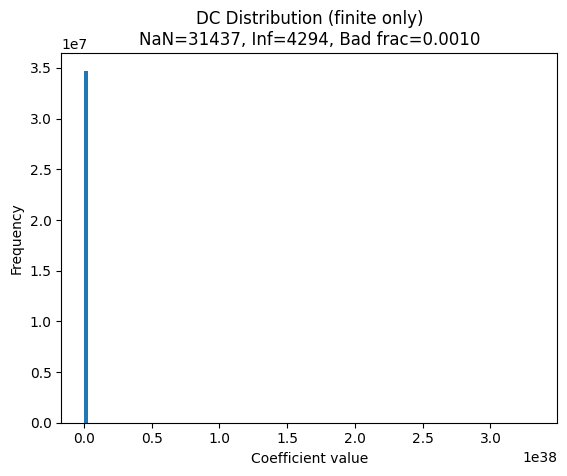

CC:
  Total values: 34764960
  NaN count: 43519
  Inf count: 2579
  Bad fraction: 0.001326
  Finite min/max: 0.0 → 3.3263642584301148e+38



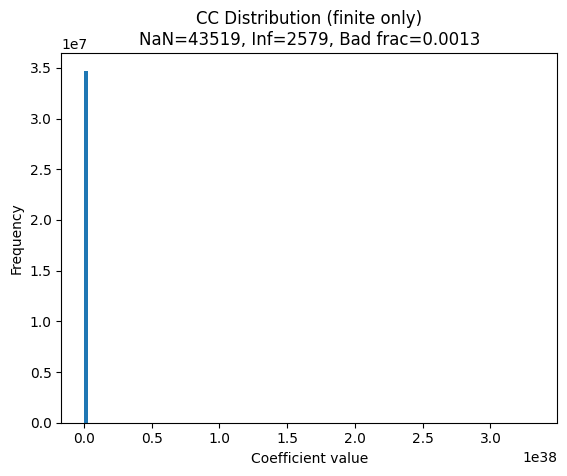

BC:
  Total values: 34764960
  NaN count: 122771
  Inf count: 1715
  Bad fraction: 0.003581
  Finite min/max: 0.0 → 3.3263642584301148e+38



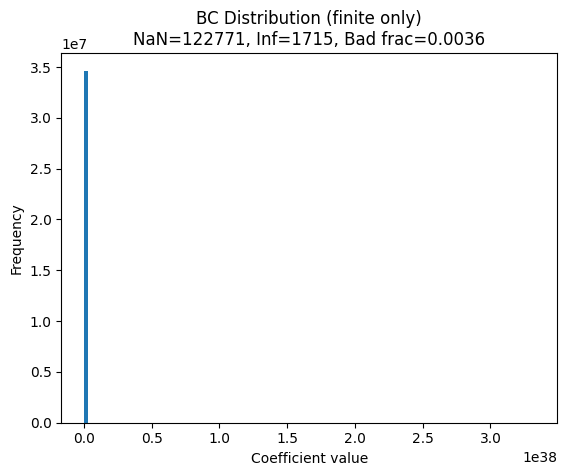

ID:
  Total values: 34764960
  NaN count: 24950
  Inf count: 865
  Bad fraction: 0.000743
  Finite min/max: 0.0 → 3.3263642584301148e+38



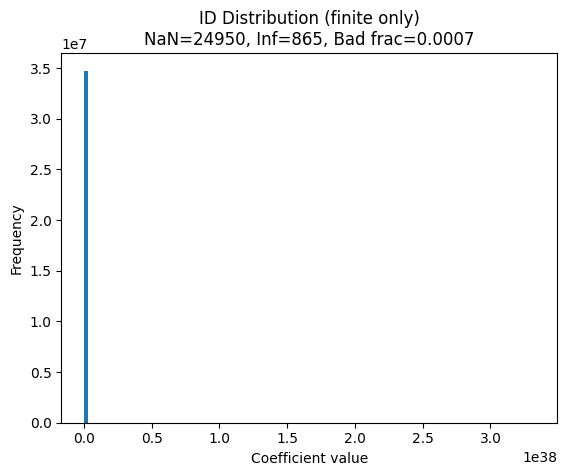

OD:
  Total values: 34764960
  NaN count: 43940
  Inf count: 864
  Bad fraction: 0.001289
  Finite min/max: 0.0 → 3.3263642584301148e+38



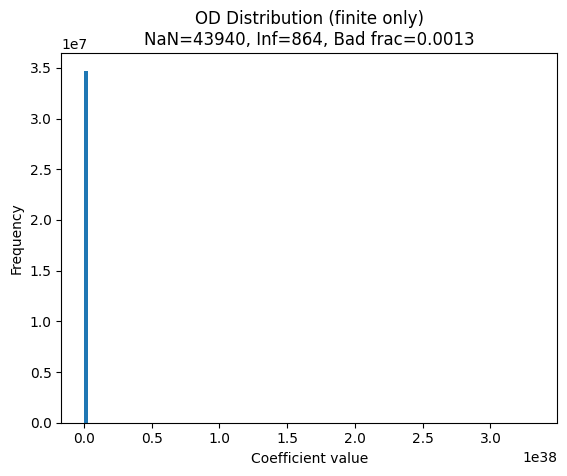

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def plot_distribution(name, da):
    values = da.values.flatten()

    nan_count = np.isnan(values).sum()
    inf_count = np.isinf(values).sum()
    total = values.size
    bad_fraction = (nan_count + inf_count) / total

    finite_vals = values[np.isfinite(values)]

    print(f"{name}:")
    print(f"  Total values: {total}")
    print(f"  NaN count: {nan_count}")
    print(f"  Inf count: {inf_count}")
    print(f"  Bad fraction: {bad_fraction:.6f}")
    print(f"  Finite min/max: {finite_vals.min()} → {finite_vals.max()}")
    print()

    plt.figure()
    plt.hist(finite_vals, bins=100)
    plt.title(f"{name} Distribution (finite only)\n"
              f"NaN={nan_count}, Inf={inf_count}, Bad frac={bad_fraction:.4f}")
    plt.xlabel("Coefficient value")
    plt.ylabel("Frequency")
    plt.show()


for name, da in [("DC", dc), ("CC", cc), ("BC", bc), ("ID", idc), ("OD", odc)]:
    plot_distribution(name, da)


DC
Total values: 34764960
NaN count: 31437
Inf count: 4294
Finite min: 0.0
Finite max: 3.3263642584301148e+38
Finite mean: inf
Finite std: inf


/opt/anaconda3/envs/aml_py310/lib/python3.10/site-packages/numpy/_core/_methods.py:135: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/opt/anaconda3/envs/aml_py310/lib/python3.10/site-packages/numpy/_core/_methods.py:171: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)


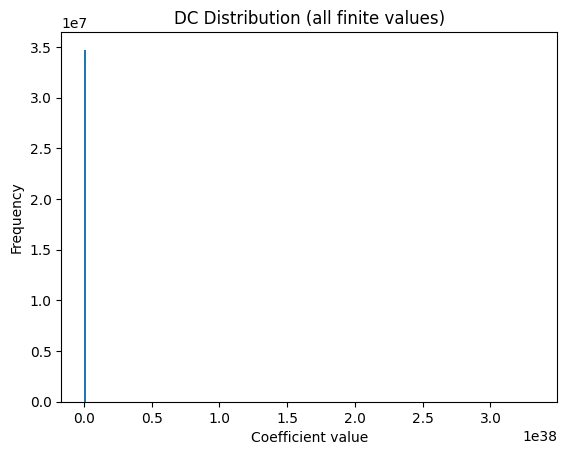


CC
Total values: 34764960
NaN count: 43519
Inf count: 2579
Finite min: 0.0
Finite max: 3.3263642584301148e+38
Finite mean: inf
Finite std: inf


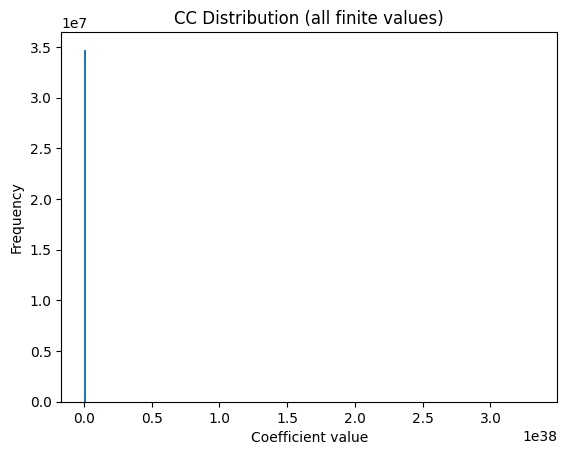


BC
Total values: 34764960
NaN count: 122771
Inf count: 1715
Finite min: 0.0
Finite max: 3.3263642584301148e+38
Finite mean: inf
Finite std: inf


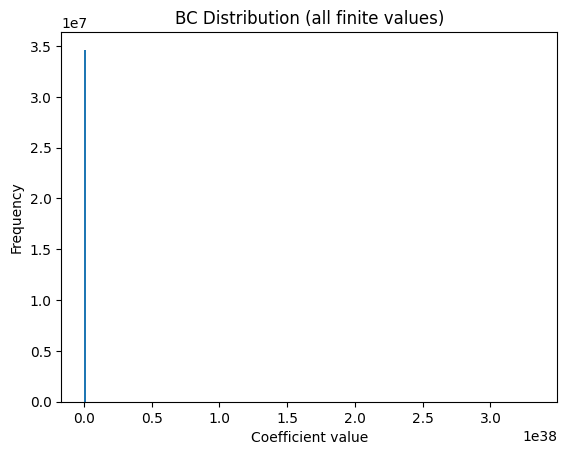


ID
Total values: 34764960
NaN count: 24950
Inf count: 865
Finite min: 0.0
Finite max: 3.3263642584301148e+38
Finite mean: inf
Finite std: inf


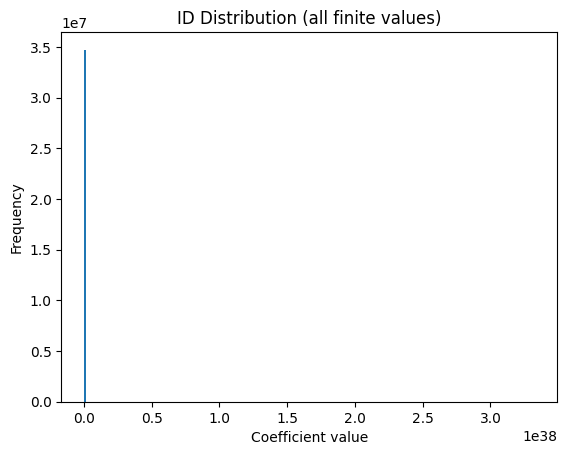


OD
Total values: 34764960
NaN count: 43940
Inf count: 864
Finite min: 0.0
Finite max: 3.3263642584301148e+38
Finite mean: inf
Finite std: inf


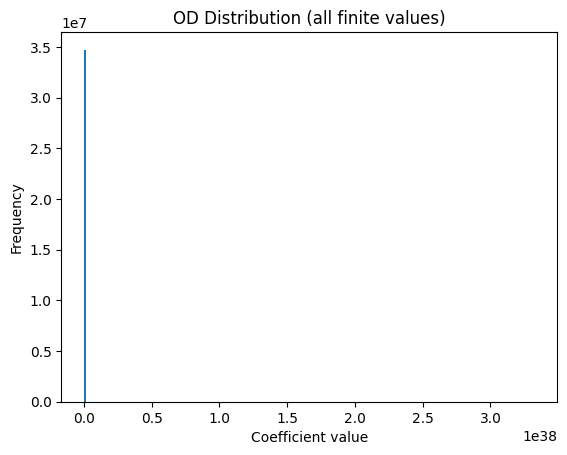

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def full_distribution(name, da):
    values = da.values.flatten()
    
    total = values.size
    nan_count = np.isnan(values).sum()
    inf_count = np.isinf(values).sum()
    
    finite_vals = values[np.isfinite(values)]
    
    print(f"\n{name}")
    print(f"Total values: {total}")
    print(f"NaN count: {nan_count}")
    print(f"Inf count: {inf_count}")
    print(f"Finite min: {finite_vals.min()}")
    print(f"Finite max: {finite_vals.max()}")
    print(f"Finite mean: {finite_vals.mean()}")
    print(f"Finite std: {finite_vals.std()}")
    
    plt.figure()
    plt.hist(finite_vals, bins=200)
    plt.title(f"{name} Distribution (all finite values)")
    plt.xlabel("Coefficient value")
    plt.ylabel("Frequency")
    plt.show()

for name, da in [("DC", dc), ("CC", cc), ("BC", bc), ("ID", idc), ("OD", odc)]:
    full_distribution(name, da)

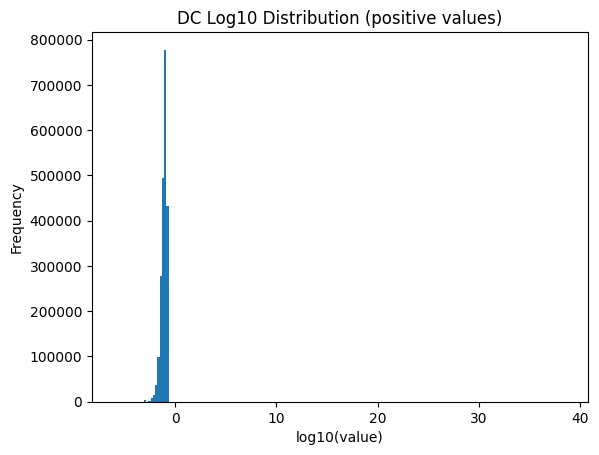

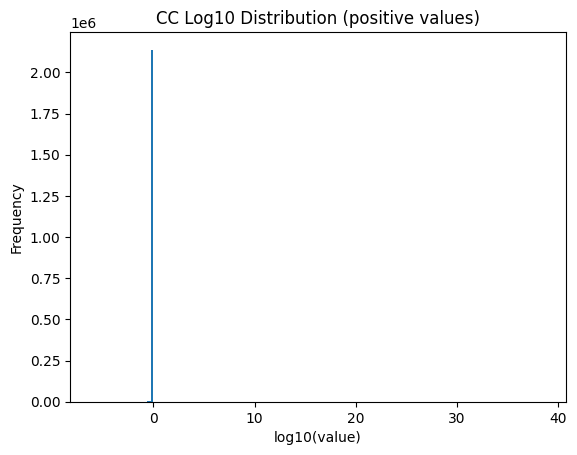

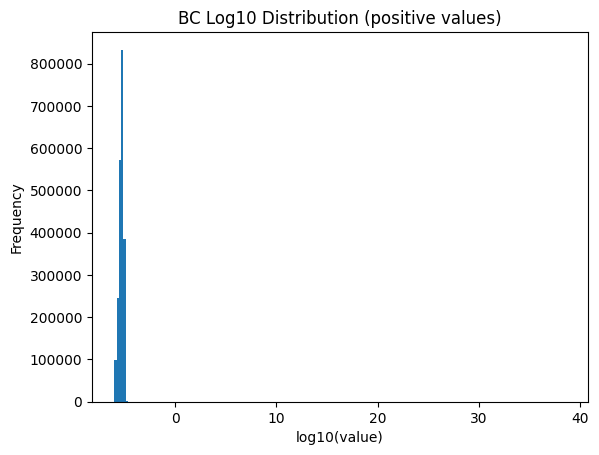

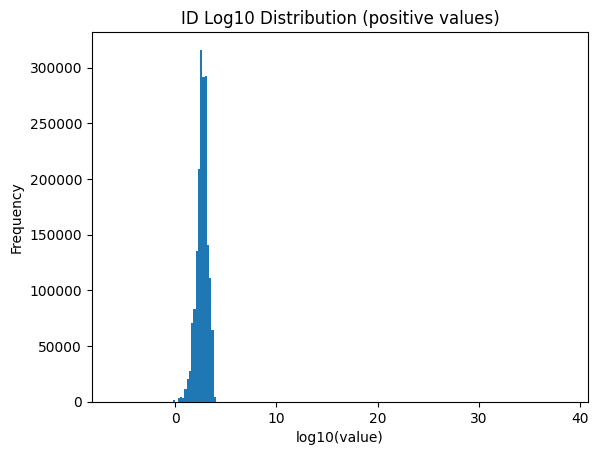

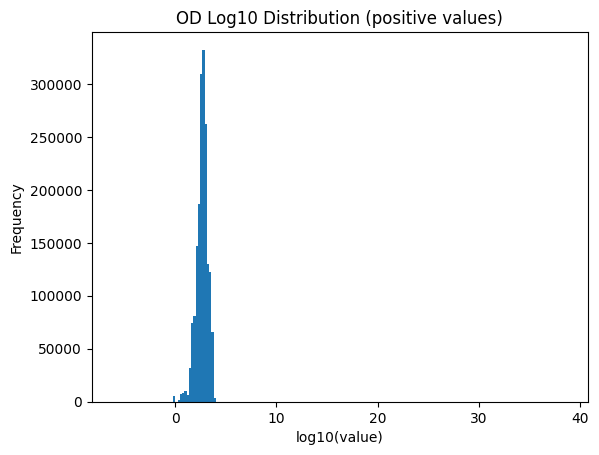

In [13]:
def log_distribution(name, da):
    values = da.values.flatten()
    finite_vals = values[np.isfinite(values)]
    
    positive_vals = finite_vals[finite_vals > 0]  # log requires positive
    
    plt.figure()
    plt.hist(np.log10(positive_vals), bins=200)
    plt.title(f"{name} Log10 Distribution (positive values)")
    plt.xlabel("log10(value)")
    plt.ylabel("Frequency")
    plt.show()

for name, da in [("DC", dc), ("CC", cc), ("BC", bc), ("ID", idc), ("OD", odc)]:
    log_distribution(name, da)

#### Finite max: 3.3263642584301148e+38 - a value that is close to the maximum representable float32 value, technically it is finite (for the is_finite() function), it might produce Nans during training 

## Data cleaning - inf and nan values

In [14]:
import numpy as np

def remove_fill_values(da):
    # mask extremely large values (NetCDF fill values)
    da = da.where(np.abs(da) < 1e10)  # threshold safely below 1e38
    return da

dc  = remove_fill_values(dc)
cc  = remove_fill_values(cc)
bc  = remove_fill_values(bc)
idc = remove_fill_values(idc)
odc = remove_fill_values(odc)

In [15]:
for name, da in [("DC", dc), ("CC", cc), ("BC", bc), ("ID", idc), ("OD", odc)]:
    print(name, "min/max:", float(da.min()), float(da.max()))

DC min/max: 0.0 8390697984.0
CC min/max: 0.0 8390697984.0
BC min/max: 0.0 8390697984.0
ID min/max: 0.0 8390697984.0
OD min/max: 0.0 8390697984.0


## Fill missing values

In [16]:
dc  = dc.fillna(0.0)
cc  = cc.fillna(0.0)
bc  = bc.fillna(0.0)
idc = idc.fillna(0.0)
odc = odc.fillna(0.0)

In [17]:
for name, da in [("DC", dc), ("CC", cc), ("BC", bc), ("ID", idc), ("OD", odc)]:
    count_extreme = ((da > 1e20).sum()).item()
    print(name, "extreme values removed:", count_extreme)

DC extreme values removed: 0
CC extreme values removed: 0
BC extreme values removed: 0
ID extreme values removed: 0
OD extreme values removed: 0


## Inspect what's the current max value


DC
Total values: 34764960
NaN count: 0
Inf count: 0
Finite min: 0.0
Finite max: 8390697984.0
Finite mean: 7800.95703125
Finite std: 6030433.5


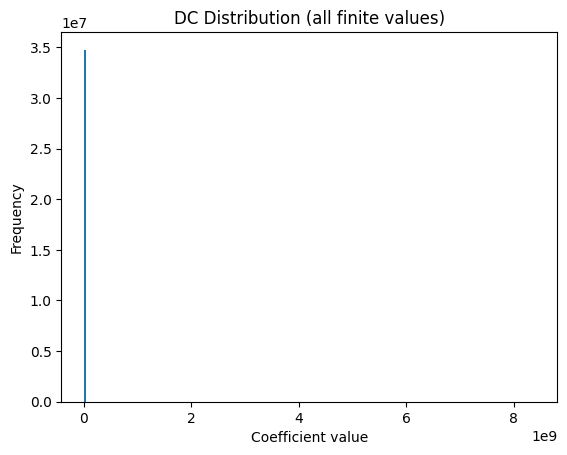


CC
Total values: 34764960
NaN count: 0
Inf count: 0
Finite min: 0.0
Finite max: 8390697984.0
Finite mean: 4680.62255859375
Finite std: 4671156.0


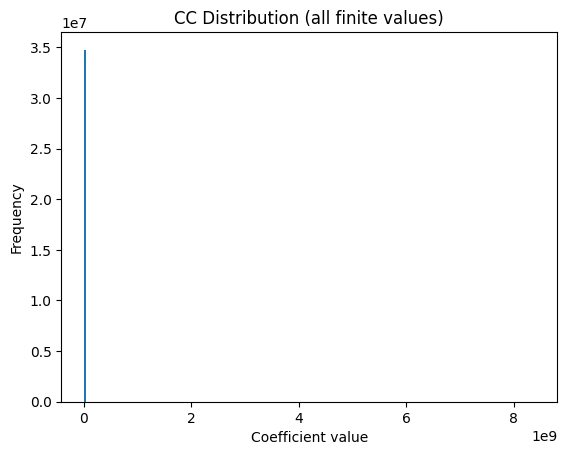


BC
Total values: 34764960
NaN count: 0
Inf count: 0
Finite min: 0.0
Finite max: 8390697984.0
Finite mean: 3120.381103515625
Finite std: 3813983.0


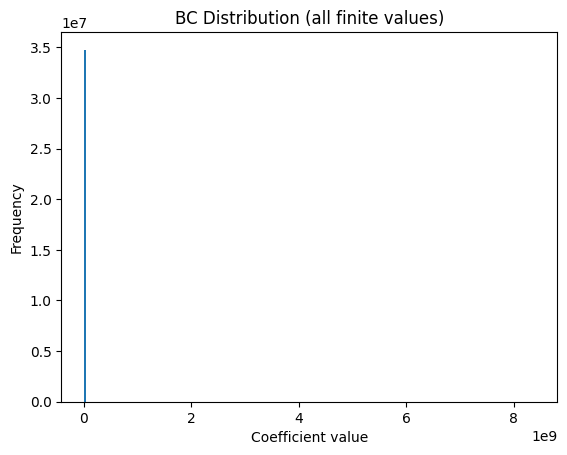


ID
Total values: 34764960
NaN count: 0
Inf count: 0
Finite min: 0.0
Finite max: 8390697984.0
Finite mean: 1605.63134765625
Finite std: 2696894.5


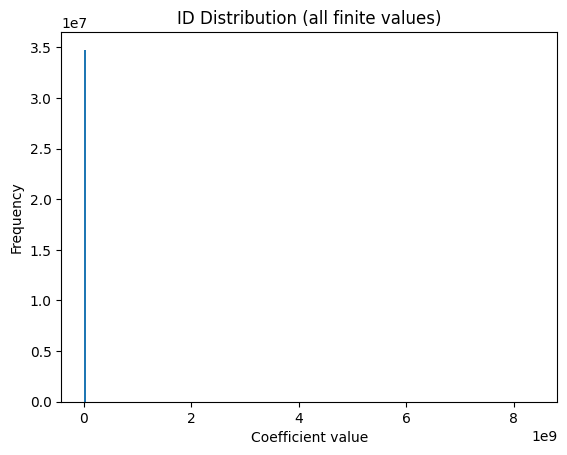


OD
Total values: 34764960
NaN count: 0
Inf count: 0
Finite min: 0.0
Finite max: 8390697984.0
Finite mean: 1605.63134765625
Finite std: 2696894.5


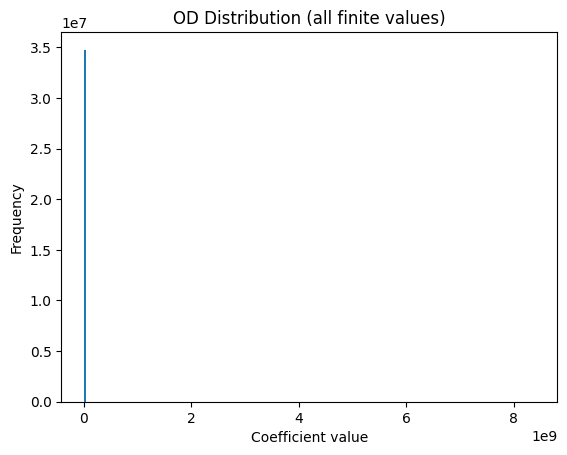

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def full_distribution(name, da):
    values = da.values.flatten()
    
    total = values.size
    nan_count = np.isnan(values).sum()
    inf_count = np.isinf(values).sum()
    
    finite_vals = values[np.isfinite(values)]
    
    print(f"\n{name}")
    print(f"Total values: {total}")
    print(f"NaN count: {nan_count}")
    print(f"Inf count: {inf_count}")
    print(f"Finite min: {finite_vals.min()}")
    print(f"Finite max: {finite_vals.max()}")
    print(f"Finite mean: {finite_vals.mean()}")
    print(f"Finite std: {finite_vals.std()}")
    
    plt.figure()
    plt.hist(finite_vals, bins=200)
    plt.title(f"{name} Distribution (all finite values)")
    plt.xlabel("Coefficient value")
    plt.ylabel("Frequency")
    plt.show()

for name, da in [("DC", dc), ("CC", cc), ("BC", bc), ("ID", idc), ("OD", odc)]:
    full_distribution(name, da)

In [19]:
import numpy as np

SENT = 8390697984.0 # large value used as a sentinel (NetCDF fill value)

def count_sentinel(name, da, sent=SENT):
    vals = da.values
    cnt = np.sum(vals == sent)
    total = vals.size
    print(f"{name}: sentinel count={cnt} ({cnt/total:.6%})")

for name, da in [("DC", dc), ("CC", cc), ("BC", bc), ("ID", idc), ("OD", odc)]:
    count_sentinel(name, da)

DC: sentinel count=5 (0.000014%)
CC: sentinel count=3 (0.000009%)
BC: sentinel count=2 (0.000006%)
ID: sentinel count=1 (0.000003%)
OD: sentinel count=1 (0.000003%)


In [ ]:
SENT = 8390697984.0

def clean_da(da):
    da = da.where(np.isfinite(da))      # drop NaN/Inf
    da = da.where(da != SENT)           # drop sentinel
    return da.fillna(0.0).astype("float32")

dc  = clean_da(dc)
cc  = clean_da(cc)
bc  = clean_da(bc)
idc = clean_da(idc)
odc = clean_da(odc)

for name, da in [("DC", dc), ("CC", cc), ("BC", bc), ("ID", idc), ("OD", odc)]:
    print(name, "min/max:", float(da.min()), float(da.max()))

DC min/max: 0.0 0.18442900478839874
CC min/max: 0.0 1.0
BC min/max: 0.0 9.999999747378752e-06
ID min/max: 0.0 4601.0
OD min/max: 0.0 4577.0


#### There's more values like this one, so instead of deleting them manually, it is best to just clip them by quantile (rare and extreme values) - those numbers are in theory finite ones, but they "contaminate" the ML process

In [21]:
def clean_and_clip(da, q=0.999):
    da = da.where(np.isfinite(da))
    hi = float(da.quantile(q))
    da = da.clip(min=0.0, max=hi)
    return da.fillna(0.0).astype("float32")

dc  = clean_and_clip(dc,  q=0.999)
cc  = clean_and_clip(cc,  q=0.999)
bc  = clean_and_clip(bc,  q=0.999)
idc = clean_and_clip(idc, q=0.999)
odc = clean_and_clip(odc, q=0.999)

for name, da in [("DC", dc), ("CC", cc), ("BC", bc), ("ID", idc), ("OD", odc)]:
    print(name, "min/max:", float(da.min()), float(da.max()))

DC min/max: 0.0 0.18442900478839874
CC min/max: 0.0 1.0
BC min/max: 0.0 9.999999747378752e-06
ID min/max: 0.0 4601.0
OD min/max: 0.0 4577.0


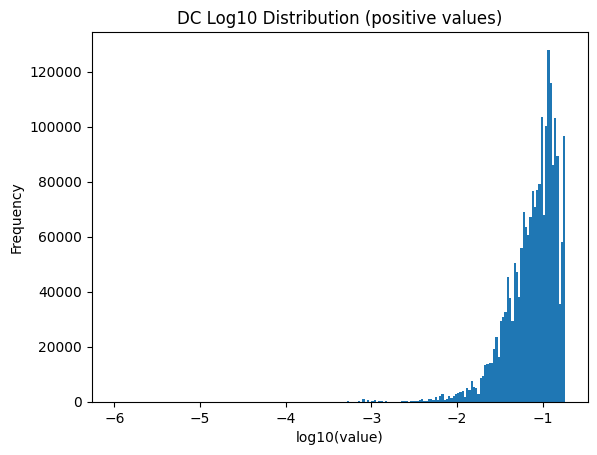

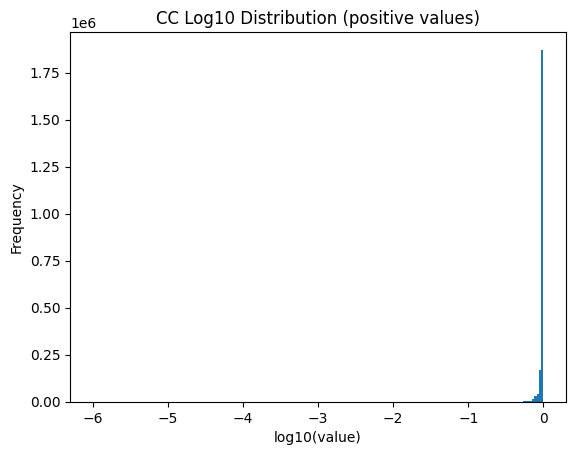

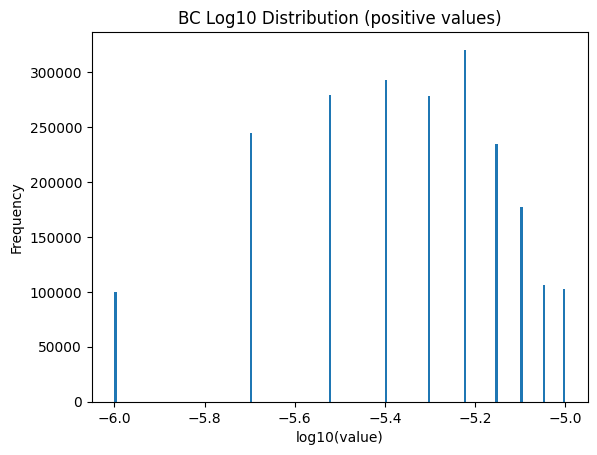

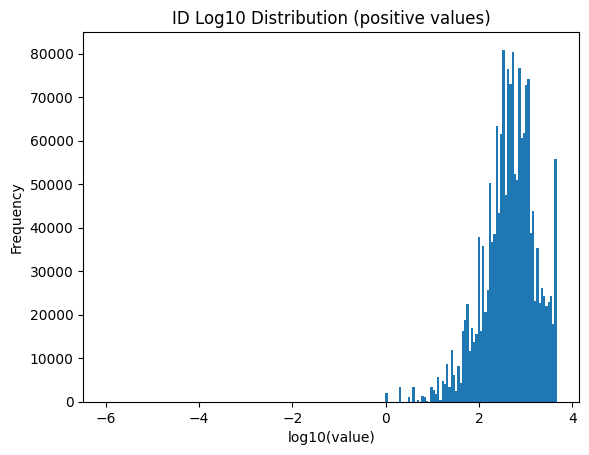

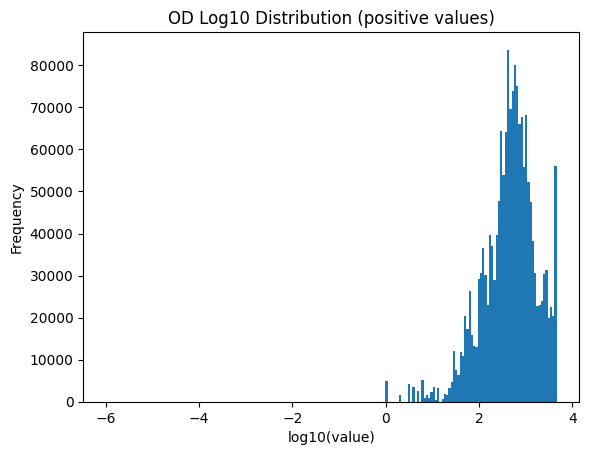

In [22]:
def log_distribution(name, da):
    values = da.values.flatten()
    finite_vals = values[np.isfinite(values)]
    
    positive_vals = finite_vals[finite_vals > 0]  # log requires positive
    
    plt.figure()
    plt.hist(np.log10(positive_vals), bins=200)
    plt.title(f"{name} Log10 Distribution (positive values)")
    plt.xlabel("log10(value)")
    plt.ylabel("Frequency")
    plt.show()

for name, da in [("DC", dc), ("CC", cc), ("BC", bc), ("ID", idc), ("OD", odc)]:
    log_distribution(name, da)

## See time range

In [23]:
print(dc.shape, cc.shape, bc.shape)
print("Time range:", str(dc.time.values[0]), "→", str(dc.time.values[-1]))

(920, 141, 268) (920, 141, 268) (920, 141, 268)
Time range: 2000-06-01T00:00:00.000000000 → 2009-08-31T00:00:00.000000000


## Load is_heatwave dataset 


In [24]:
import xarray as xr

ds = xr.open_dataset("data/is_heatwave/Europe_0.25deg/Europe_0.25deg_1990-06-01_1990-07-01_ishw.nc")
print(ds)
print("vars:", list(ds.data_vars))

v = list(ds.data_vars)[0]
print("chosen var:", v)
print("dtype:", ds[v].dtype)
print("min/max:", float(ds[v].min()), float(ds[v].max()))

<xarray.Dataset> Size: 9MB
Dimensions:      (time: 30, x: 141, y: 268)
Coordinates:
  * time         (time) datetime64[ns] 240B 1990-06-01 1990-06-02 ... 1990-06-30
  * x            (x) float64 1kB 35.88 36.12 36.38 36.62 ... 70.38 70.62 70.88
  * y            (y) float64 2kB -25.88 -25.62 -25.38 ... 40.38 40.62 40.88
Data variables:
    is_heatwave  (time, x, y) float64 9MB ...
vars: ['is_heatwave']
chosen var: is_heatwave
dtype: float64
min/max: 0.0 1.0


In [25]:
import xarray as xr
import numpy as np
import glob
import re
from pathlib import Path

def parse_year_month_from_filename(fname: str):
    # works with: Europe_0.25deg_1990-06-01_1990-07-01_ishw.nc
    m = re.search(r'(\d{4})-(\d{2})-01', fname)
    if not m:
        raise ValueError(f"Can't parse year-month from {fname}")
    return int(m.group(1)), int(m.group(2))

def open_is_heatwave_month(path: str, var_name: str):
    ds = xr.open_dataset(path).drop_duplicates("time")
    year, month = parse_year_month_from_filename(Path(path).name)
    # keep only the intended month (drops the 1st of next month)
    ds = ds.sel(time=(ds.time.dt.year == year) & (ds.time.dt.month == month))
    return ds[var_name]

def load_is_heatwave(root_dir: str, var_name: str = None):
    """
    Loads all monthly is_heatwave files under root_dir and concatenates them.
    root_dir example: data/is_heatwave/Europe_0.25deg/
    """
    paths = sorted(glob.glob(f"{root_dir}/**/*.nc", recursive=True))
    if not paths:
        raise ValueError(f"No .nc files found under {root_dir}")

    # auto-detect var name if not given
    if var_name is None:
        test = xr.open_dataset(paths[0])
        if len(test.data_vars) != 1:
            raise ValueError(f"Expected 1 data var, found {list(test.data_vars)}. Please set var_name explicitly.")
        var_name = list(test.data_vars)[0]
        test.close()

    arrays = [open_is_heatwave_month(p, var_name=var_name) for p in paths]
    hw = xr.concat(arrays, dim="time").sortby("time").drop_duplicates("time")

    # ensure it's really binary-ish
    hw = hw.astype(np.float32)
    return hw, var_name

## x -> lat and y -> lon

In [26]:
hw, hw_var = load_is_heatwave("data/is_heatwave/Europe_0.25deg")
hw = hw.rename({"x": "lat", "y": "lon"})
print("Loaded var:", hw_var)
print(hw)
print("min/max:", float(hw.min()), float(hw.max()))

Loaded var: is_heatwave
<xarray.DataArray 'is_heatwave' (time: 2852, lat: 141, lon: 268)> Size: 431MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 1., 1., 0.],
        [0., 0., 0., ..., 1., 1., 1.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 

## Align the datasets together

In [27]:
import numpy as np
import xarray as xr

def align_common_time(*das):
    common = das[0].time.values
    for da in das[1:]:
        common = np.intersect1d(common, da.time.values)
    common = xr.DataArray(common, dims="time")
    return [da.sel(time=common) for da in das]

dc, cc, bc, idc, odc, hw = align_common_time(dc, cc, bc, idc, odc, hw)

print("Aligned time length:", dc.sizes["time"])
print("Time range:", str(dc.time.values[0]), "→", str(dc.time.values[-1]))

Aligned time length: 920
Time range: 2000-06-01T00:00:00.000000000 → 2009-08-31T00:00:00.000000000


In [28]:
import numpy as np

# sort
dc_s = dc.sortby("lat").sortby("lon")
hw_s = hw.sortby("lat").sortby("lon")

# map hw grid onto dc grid
hw_on_dc = hw_s.reindex(lat=dc_s.lat, lon=dc_s.lon, method="nearest", tolerance=0.2)

# fill any remaining missing due to tolerance
hw_on_dc = hw_on_dc.fillna(0.0).astype("float32")

print("Spatial dims:", hw_on_dc.sizes["lat"], hw_on_dc.sizes["lon"])
print("lat equal:", np.array_equal(hw_on_dc.lat.values, dc_s.lat.values))
print("lon equal:", np.array_equal(hw_on_dc.lon.values, dc_s.lon.values))

Spatial dims: 141 268
lat equal: True
lon equal: True


In [29]:
def coord_summary(name, da):
    print(f"{name}: lat[{da.lat.size}] {float(da.lat.min()):.3f}→{float(da.lat.max()):.3f} | "
          f"lon[{da.lon.size}] {float(da.lon.min()):.3f}→{float(da.lon.max()):.3f}")

coord_summary("hw", hw)
coord_summary("dc", dc)
coord_summary("cc", cc)
coord_summary("bc", bc)
coord_summary("idc", idc)
coord_summary("odc", odc)

hw: lat[141] 35.875→70.875 | lon[268] -25.875→40.875
dc: lat[141] 35.800→71.000 | lon[268] -26.000→41.000
cc: lat[141] 35.800→71.000 | lon[268] -26.000→41.000
bc: lat[141] 35.800→71.000 | lon[268] -26.000→41.000
idc: lat[141] 35.800→71.000 | lon[268] -26.000→41.000
odc: lat[141] 35.800→71.000 | lon[268] -26.000→41.000


#### The heatwave indicator grid was reindexed to the CN coefficient grid using nearest-neighbor mapping to ensure consistent spatial alignment.

In [30]:
import numpy as np

# Ensure sorted coordinate order
dc_s = dc.sortby("lat").sortby("lon")
hw_s = hw.sortby("lat").sortby("lon")

# Reindex heatwave to coefficient grid using nearest neighbor
hw_on_dc = hw_s.reindex(lat=dc_s.lat, lon=dc_s.lon, method="nearest", tolerance=0.2)

# Check if any NaNs were introduced (tolerance too strict)
print("NaNs after reindex:", bool(np.isnan(hw_on_dc.isel(time=0).values).any()))
print("hw_on_dc grid:", float(hw_on_dc.lat.min()), float(hw_on_dc.lat.max()),
      float(hw_on_dc.lon.min()), float(hw_on_dc.lon.max()))

NaNs after reindex: False
hw_on_dc grid: 35.79999923706055 71.0 -26.0 41.0


In [31]:
import xarray as xr

def align_common_time(*das):
    common = das[0].time.values
    for da in das[1:]:
        common = np.intersect1d(common, da.time.values)
    common = xr.DataArray(common, dims="time")
    return [da.sel(time=common) for da in das]

dc_s, cc_s, bc_s, idc_s, odc_s, hw_on_dc = align_common_time(
    dc_s, cc.sortby("lat").sortby("lon"), bc.sortby("lat").sortby("lon"),
    idc.sortby("lat").sortby("lon"), odc.sortby("lat").sortby("lon"),
    hw_on_dc
)

print("time equal:", np.array_equal(dc_s.time.values, hw_on_dc.time.values))
print("lat equal:", np.array_equal(dc_s.lat.values, hw_on_dc.lat.values))
print("lon equal:", np.array_equal(dc_s.lon.values, hw_on_dc.lon.values))

print("hw min/max:", float(hw_on_dc.min()), float(hw_on_dc.max()))
print("bc min/max:", float(bc_s.min()), float(bc_s.max()))

time equal: True
lat equal: True
lon equal: True
hw min/max: 0.0 1.0
bc min/max: 0.0 9.999999747378752e-06


## Build X and next-day target Y

In [ ]:
import xarray as xr

COEFFS = ["DC", "CC", "BC", "ID", "OD"]

# X coefficients at time t
Xc = xr.concat([dc_s, cc_s, bc_s, idc_s, odc_s], dim="channel").assign_coords(channel=COEFFS)

# heatwave at time t as extra channel
hw_t = hw_on_dc.astype("float32").expand_dims(channel=["HW"])

# full input X at time t: 6 channels
X = xr.concat([Xc, hw_t], dim="channel")

# target y at time t+1
y = hw_on_dc.shift(time=-1)

# drop last time step (because y(t+1) missing at end)
X = X.isel(time=slice(None, -1))
y = y.isel(time=slice(None, -1))

print("X:", X.dims, X.shape)   
print("y:", y.dims, y.shape)
print("channels:", list(X.channel.values))

X: ('channel', 'time', 'lat', 'lon') (6, 919, 141, 268)
y: ('time', 'lat', 'lon') (919, 141, 268)
channels: ['DC', 'CC', 'BC', 'ID', 'OD', 'HW']


## Adjust to the Iberia region

In [33]:
# Iberia bounding box 
lon_min, lon_max = -10, 4
lat_min, lat_max = 36, 44

X_ib = X.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
y_ib = y.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))

print("X_ib:", X_ib.shape, X_ib.dims)
print("y_ib:", y_ib.shape, y_ib.dims)

X_ib: (6, 919, 32, 56) ('channel', 'time', 'lat', 'lon')
y_ib: (919, 32, 56) ('time', 'lat', 'lon')


## Use the range 2001-2003

In [34]:
X_0103 = X_ib.sel(time=slice("2001-06-01", "2003-08-31"))
y_0103 = y_ib.sel(time=slice("2001-06-01", "2003-08-31"))

print("Time range:", str(X_0103.time.values[0]), "→", str(X_0103.time.values[-1]))

Time range: 2001-06-01T00:00:00.000000000 → 2003-08-31T00:00:00.000000000


## Yearly sequences

In [35]:
import numpy as np

def make_sequences_per_year(X, y, seq_len=14):
    """
    X: (channel, time, lat, lon)
    y: (time, lat, lon)
    Returns:
      X_seq: (N, seq_len, C, H, W)
      y_seq: (N, 1, H, W)
      y_dates: (N,) numpy datetime64 array = date of the target day
    """
    # time-first arrays
    Xt = X.transpose("time", "channel", "lat", "lon")
    yt = y.transpose("time", "lat", "lon")

    years = np.unique(Xt.time.dt.year.values)
    X_list, y_list, d_list = [], [], []

    for yr in years:
        Xy = Xt.sel(time=str(yr))
        yy = yt.sel(time=str(yr))

        T = Xy.sizes["time"]
        if T <= seq_len:
            continue

        Xv = Xy.values  # (T, C, H, W)
        yv = yy.values  # (T, H, W)
        times = Xy.time.values

        for i in range(T - seq_len):
            X_list.append(Xv[i:i+seq_len])
            y_list.append(yv[i+seq_len])         # predict next day after the window
            d_list.append(times[i+seq_len])      # store target day timestamp

    X_seq = np.stack(X_list).astype(np.float32)          # (N, L, C, H, W)
    y_seq = np.stack(y_list).astype(np.float32)[:, None] # (N, 1, H, W)
    y_dates = np.array(d_list)

    return X_seq, y_seq, y_dates

seq_len = 14
X_seq, y_seq, y_dates = make_sequences_per_year(X_0103, y_0103, seq_len=seq_len)

print("X_seq:", X_seq.shape)
print("y_seq:", y_seq.shape)
print("Target dates:", y_dates[0], "→", y_dates[-1])
print("y unique (sample):", np.unique(y_seq[:1]))

X_seq: (234, 14, 6, 32, 56)
y_seq: (234, 1, 32, 56)
Target dates: 2001-06-15T00:00:00.000000000 → 2003-08-31T00:00:00.000000000
y unique (sample): [0. 1.]


In [36]:
import numpy as np

y_dates_d = y_dates.astype("datetime64[D]")

train_mask = (y_dates_d >= np.datetime64("2001-06-01")) & (y_dates_d <= np.datetime64("2002-08-31"))
val_mask   = (y_dates_d >= np.datetime64("2003-06-01")) & (y_dates_d <= np.datetime64("2003-07-15"))
test_mask  = (y_dates_d >= np.datetime64("2003-07-16")) & (y_dates_d <= np.datetime64("2003-08-31"))

X_train, y_train = X_seq[train_mask], y_seq[train_mask]
X_val,   y_val   = X_seq[val_mask],   y_seq[val_mask]
X_test,  y_test  = X_seq[test_mask],  y_seq[test_mask]
test_dates = y_dates_d[test_mask]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)
print("Test dates:", test_dates[0], "→", test_dates[-1])

print("Heatwave fraction train/val/test:",
      float(y_train.mean()), float(y_val.mean()), float(y_test.mean()))

Train: (156, 14, 6, 32, 56) (156, 1, 32, 56)
Val:   (31, 14, 6, 32, 56) (31, 1, 32, 56)
Test:  (47, 14, 6, 32, 56) (47, 1, 32, 56)
Test dates: 2003-07-16 → 2003-08-31
Heatwave fraction train/val/test: 0.06266812980175018 0.16535858809947968 0.18508976697921753


#### Final check after split (to ensure no NaN or inf values)

In [37]:
print("Raw NaN in X_train:", np.isnan(X_train).any(), "Inf:", np.isinf(X_train).any())

Raw NaN in X_train: False Inf: False


Test tensor (47, 14, 5, 32, 56):
47 different target days
14 day input window 
5 channels 
Iberia grid 32x56

### Split - Train: 2001–2002, Val: 2003-06-01 → 2003-07-31, Test: 2003-08-01 → 2003-08-31

In [38]:
val_mask   = (y_dates_d >= np.datetime64("2003-06-01")) & (y_dates_d <= np.datetime64("2003-07-31"))
test_mask  = (y_dates_d >= np.datetime64("2003-08-01")) & (y_dates_d <= np.datetime64("2003-08-31"))

In [39]:
def normalize_per_channel(X_train, X_val, X_test, eps=1e-6):
    mean = X_train.mean(axis=(0,1,3,4), keepdims=True)
    std  = X_train.std(axis=(0,1,3,4), keepdims=True)
    return ((X_train - mean) / (std + eps),
            (X_val   - mean) / (std + eps),
            (X_test  - mean) / (std + eps),
            mean, std)

X_train_n, X_val_n, X_test_n, mean, std = normalize_per_channel(X_train, X_val, X_test)

## ConvLSTM

In [40]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class NumpySeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()  # (N, L, C, H, W)
        self.y = torch.from_numpy(y).float()  # (N, 1, H, W)
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, i): return self.X[i], self.y[i]

class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2
        self.hidden_dim = hidden_dim
        self.conv = nn.Conv2d(input_dim + hidden_dim, 4 * hidden_dim,
                              kernel_size=kernel_size, padding=padding)

    def forward(self, x, h, c):
        # x: (B, Cin, H, W), h/c: (B, Chid, H, W)
        combined = torch.cat([x, h], dim=1)
        gates = self.conv(combined)
        i, f, o, g = torch.chunk(gates, 4, dim=1)
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

class ConvLSTM(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=32, kernel_size=3):
        super().__init__()
        self.cell = ConvLSTMCell(input_dim, hidden_dim, kernel_size)
        self.head = nn.Conv2d(hidden_dim, 1, kernel_size=1)

    def forward(self, x):
        # x: (B, L, C, H, W)
        B, L, C, H, W = x.shape
        h = torch.zeros(B, self.cell.hidden_dim, H, W, device=x.device)
        c = torch.zeros(B, self.cell.hidden_dim, H, W, device=x.device)

        for t in range(L):
            h, c = self.cell(x[:, t], h, c)

        logits = self.head(h)  # (B, 1, H, W)
        return logits

In [42]:
device = "cuda" if torch.cuda.is_available() else "cpu"

train_ds = NumpySeqDataset(X_train_n, y_train)
val_ds   = NumpySeqDataset(X_val_n, y_val)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False)

model = ConvLSTM(input_dim=6, hidden_dim=32, kernel_size=3).to(device)

# pos_weight = (#neg / #pos) over training pixels
pos = float(y_train.sum())
neg = float(y_train.size - y_train.sum())
pos_weight = torch.tensor([neg / (pos + 1e-6)], device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

def evaluate(loader):
    model.eval()
    losses = []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            loss = criterion(logits, yb)
            losses.append(loss.item())
    return float(np.mean(losses))

for epoch in range(1, 11):
    model.train()
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        opt.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        opt.step()

    val_loss = evaluate(val_loader)
    print(f"Epoch {epoch:02d} | val_loss={val_loss:.4f}")

Epoch 01 | val_loss=1.5810
Epoch 02 | val_loss=1.4954
Epoch 03 | val_loss=1.5439
Epoch 04 | val_loss=1.4992
Epoch 05 | val_loss=1.4483
Epoch 06 | val_loss=1.4642
Epoch 07 | val_loss=1.4674
Epoch 08 | val_loss=1.4455
Epoch 09 | val_loss=1.4897
Epoch 10 | val_loss=1.4350


## Evaluation

In [43]:
from sklearn.metrics import f1_score

test_ds = NumpySeqDataset(X_test_n, y_test)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)

model.eval()
all_pred = []
all_true = []

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        logits = model(Xb)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_pred.append(probs)
        all_true.append(yb.numpy())

pred = np.concatenate(all_pred, axis=0)  # (N, 1, H, W)
true = np.concatenate(all_true, axis=0)

# threshold at 0.5
pred_bin = (pred >= 0.5).astype(np.uint8)
true_bin = (true >= 0.5).astype(np.uint8)

# pixel F1 (flatten all pixels)
f1 = f1_score(true_bin.ravel(), pred_bin.ravel())
print("Test pixel F1:", f1)

# IoU (Jaccard) over pixels
intersection = (pred_bin & true_bin).sum()
union = (pred_bin | true_bin).sum()
iou = (intersection / (union + 1e-6))
print("Test IoU:", float(iou))

Test pixel F1: 0.6121685299824448
Test IoU: 0.4410971671901369


## Metrics


In [44]:
from sklearn.metrics import average_precision_score

ap = average_precision_score(true_bin.ravel(), pred.ravel())
print("Test Average Precision (PR-AUC):", ap)

Test Average Precision (PR-AUC): 0.6391235217955689


## Visualise the predictions (1st of August 2003)

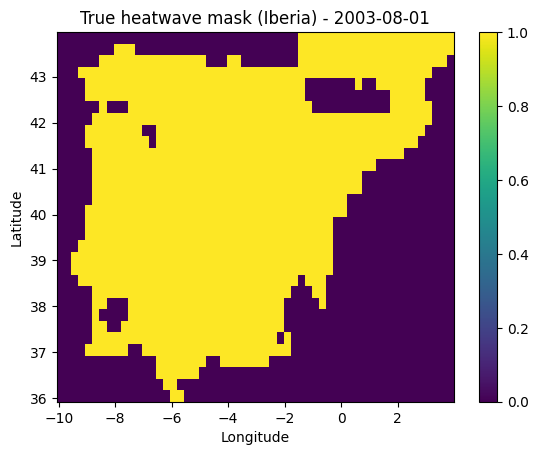

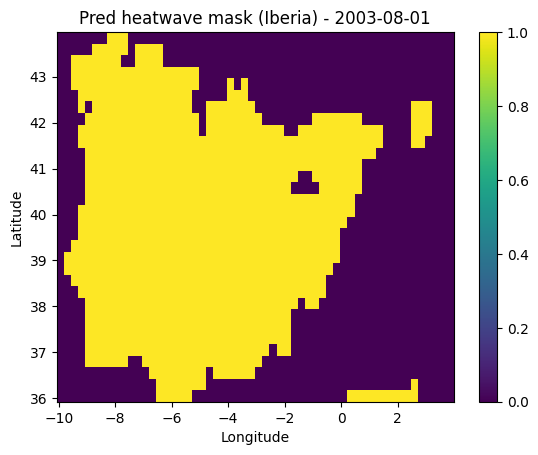

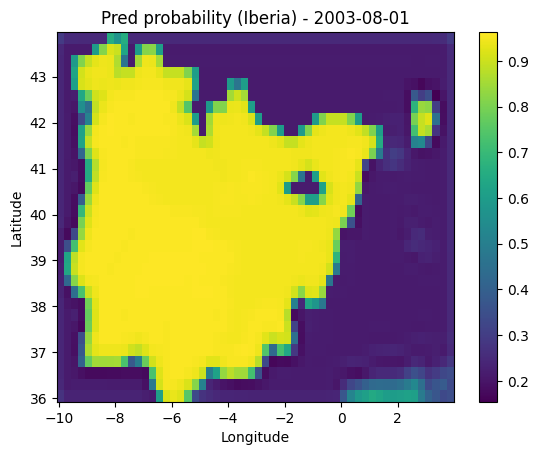

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Find index of August 1
target_date = np.datetime64("2003-08-01")
idx = np.where(test_dates == target_date)[0][0]

prob_map = pred[idx, 0]        # predicted probabilities
true_map = true[idx, 0]        # true heatwave mask
pred_map = (prob_map >= 0.5).astype(int)

lats = y_ib.lat.values
lons = y_ib.lon.values

def plot_mask_lonlat(mask, title):
    plt.figure()
    plt.pcolormesh(lons, lats, mask, shading="auto")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(title)
    plt.colorbar()
    plt.show()

# Example: pick one test index (or your August 1 idx)
plot_mask_lonlat(true_map, "True heatwave mask (Iberia) - 2003-08-01")
plot_mask_lonlat(pred_map, "Pred heatwave mask (Iberia) - 2003-08-01")
plot_mask_lonlat(prob_map, "Pred probability (Iberia) - 2003-08-01")

So given the past 14 days, the model predicts there is an (for example) 82% chance that tomorrow this location is in heatwave. IoU compares: 

Predicted region  ∩  True region / Predicted region  ∪  True region

## Predict Clustering Coefficient (CC) instead of is_heatwave

In [ ]:
import xarray as xr

COEFFS = ["DC", "CC", "BC", "ID", "OD"]

# X coefficients at time t
Xc = xr.concat([dc_s, cc_s, bc_s, idc_s, odc_s], dim="channel").assign_coords(channel=COEFFS)

# heatwave at time t as extra channel
# hw_t = hw_on_dc.astype("float32").expand_dims(channel=["HW"])

# full input X at time t: 6 channels
# X = xr.concat([Xc, hw_t], dim="channel")

# target y at time t+1
y = cc_s.shift(time=-1).expand_dims(channel=["CC_next"])

# drop last time step (because y(t+1) missing at end)
X = Xc.isel(time=slice(None, -1))
y = y.isel(time=slice(None, -1))

print("X:", X.dims, X.shape)   
print("y:", y.dims, y.shape)
print("channels:", list(X.channel.values))

X: ('channel', 'time', 'lat', 'lon') (5, 919, 141, 268)
y: ('time', 'lat', 'lon') (919, 141, 268)
channels: [np.str_('DC'), np.str_('CC'), np.str_('BC'), np.str_('ID'), np.str_('OD')]


## Iberia region

In [64]:
# Iberia bounding box 
lon_min, lon_max = -10, 4
lat_min, lat_max = 36, 44

X_ib = X.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
y_ib = y.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))

print("X_ib:", X_ib.shape, X_ib.dims)
print("y_ib:", y_ib.shape, y_ib.dims)

X_ib: (5, 919, 32, 56) ('channel', 'time', 'lat', 'lon')
y_ib: (919, 32, 56) ('time', 'lat', 'lon')


In [65]:
X_0103 = X_ib.sel(time=slice("2001-06-01", "2003-08-31"))
y_0103 = y_ib.sel(time=slice("2001-06-01", "2003-08-31"))

print("Time range:", str(X_0103.time.values[0]), "→", str(X_0103.time.values[-1]))

Time range: 2001-06-01T00:00:00.000000000 → 2003-08-31T00:00:00.000000000


## Yearly sequences

In [66]:
seq_len = 14
X_seq, y_seq, y_dates = make_sequences_per_year(X_0103, y_0103, seq_len=seq_len)

print("X_seq:", X_seq.shape)
print("y_seq:", y_seq.shape)
print("Target dates:", y_dates[0], "→", y_dates[-1])
print("y unique (sample):", np.unique(y_seq[:1]))

X_seq: (234, 14, 5, 32, 56)
y_seq: (234, 1, 32, 56)
Target dates: 2001-06-15T00:00:00.000000000 → 2003-08-31T00:00:00.000000000
y unique (sample): [0.       0.999635]


In [67]:
import numpy as np

y_dates_d = y_dates.astype("datetime64[D]")

train_mask = (y_dates_d >= np.datetime64("2001-06-01")) & (y_dates_d <= np.datetime64("2002-08-31"))
val_mask   = (y_dates_d >= np.datetime64("2003-06-01")) & (y_dates_d <= np.datetime64("2003-07-15"))
test_mask  = (y_dates_d >= np.datetime64("2003-07-16")) & (y_dates_d <= np.datetime64("2003-08-31"))

X_train, y_train = X_seq[train_mask], y_seq[train_mask]
X_val,   y_val   = X_seq[val_mask],   y_seq[val_mask]
X_test,  y_test  = X_seq[test_mask],  y_seq[test_mask]
test_dates = y_dates_d[test_mask]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)
print("Test dates:", test_dates[0], "→", test_dates[-1])

print("Heatwave fraction train/val/test:",
      float(y_train.mean()), float(y_val.mean()), float(y_test.mean()))

Train: (156, 14, 5, 32, 56) (156, 1, 32, 56)
Val:   (31, 14, 5, 32, 56) (31, 1, 32, 56)
Test:  (47, 14, 5, 32, 56) (47, 1, 32, 56)
Test dates: 2003-07-16 → 2003-08-31
Heatwave fraction train/val/test: 0.06931030005216599 0.19343096017837524 0.1944824755191803


In [68]:
val_mask   = (y_dates_d >= np.datetime64("2003-06-01")) & (y_dates_d <= np.datetime64("2003-07-31"))
test_mask  = (y_dates_d >= np.datetime64("2003-08-01")) & (y_dates_d <= np.datetime64("2003-08-31"))

X_train_n, X_val_n, X_test_n, mean, std = normalize_per_channel(X_train, X_val, X_test)

In [69]:
print("y nan:", bool(np.isnan(y.values).any()), "inf:", bool(np.isinf(y.values).any()))
print("y min/max:", float(y.min()), float(y.max()))

y nan: False inf: False
y min/max: 0.0 1.0


## Normalise target step 

In [70]:
def normalize_target(y_train, y_val, y_test, eps=1e-6):
    mean = y_train.mean()
    std  = y_train.std()
    return ((y_train - mean) / (std + eps),
            (y_val   - mean) / (std + eps),
            (y_test  - mean) / (std + eps),
            mean, std)

y_train_n, y_val_n, y_test_n, y_mean, y_std = normalize_target(y_train, y_val, y_test)

In [73]:
device = "cuda" if torch.cuda.is_available() else "cpu"

train_ds = NumpySeqDataset(X_train_n, y_train)
val_ds   = NumpySeqDataset(X_val_n, y_val)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False)

model = ConvLSTM(input_dim=5, hidden_dim=32, kernel_size=3).to(device)

# pos_weight = (#neg / #pos) over training pixels
pos = float(y_train.sum())
neg = float(y_train.size - y_train.sum())
pos_weight = torch.tensor([neg / (pos + 1e-6)], device=device)

criterion = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1, 11):
    model.train()
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        opt.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        opt.step()

    val_loss = evaluate(val_loader)
    print(f"Epoch {epoch:02d} | val_loss={val_loss:.4f}")

Epoch 01 | val_loss=0.1086
Epoch 02 | val_loss=0.0883
Epoch 03 | val_loss=0.0839
Epoch 04 | val_loss=0.0856
Epoch 05 | val_loss=0.0839
Epoch 06 | val_loss=0.0832
Epoch 07 | val_loss=0.0832
Epoch 08 | val_loss=0.0802
Epoch 09 | val_loss=0.0891
Epoch 10 | val_loss=0.0815


In [85]:
from torch.utils.data import DataLoader
import numpy as np

test_ds = NumpySeqDataset(X_test_n, y_test_n)   # <-- NOTE: y_test_n, not y_test
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)

model.eval()
all_pred = []
all_true = []

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        pred_n = model(Xb).cpu().numpy()   # <-- raw output, no sigmoid
        all_pred.append(pred_n)
        all_true.append(yb.numpy())

pred_n = np.concatenate(all_pred, axis=0)   # (N, 1, H, W) normalized predictions
true_n = np.concatenate(all_true, axis=0)   # (N, 1, H, W) normalized ground truth

# Unnormalize back to CC scale
pred = pred_n * y_std + y_mean
true = true_n * y_std + y_mean

# Regression metrics
mse  = np.mean((pred - true)**2)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(pred - true))

print("Test RMSE (CC):", float(rmse))
print("Test MAE  (CC):", float(mae))

Test RMSE (CC): 0.3561892807483673
Test MAE  (CC): 0.21967479586601257


## Visualise the predictions of Clustering Coefficient (CC) - (1st of August 2003)

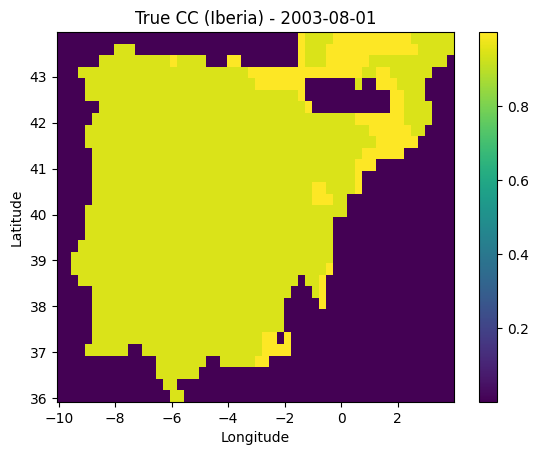

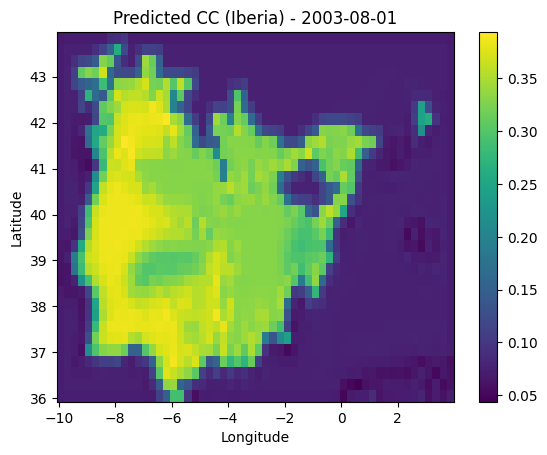

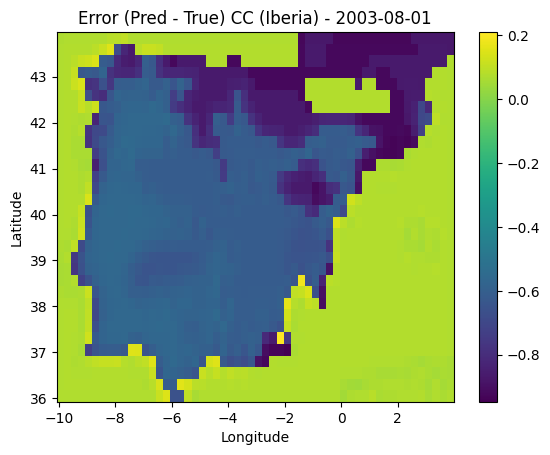

In [86]:
import numpy as np
import matplotlib.pyplot as plt

# pick a target date OR just pick an index
target_date = np.datetime64("2003-08-01")

# find index in test set
idx = int(np.where(test_dates == target_date)[0][0])

pred_map = pred[idx, 0]   # (H,W)
true_map = true[idx, 0]
err_map  = pred_map - true_map

lats = y_ib.lat.values
lons = y_ib.lon.values

def plot_cc_lonlat(field, title):
    plt.figure()
    plt.pcolormesh(lons, lats, field, shading="auto")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(title)
    plt.colorbar()
    plt.show()

plot_cc_lonlat(true_map, f"True CC (Iberia) - {str(target_date)}")
plot_cc_lonlat(pred_map, f"Predicted CC (Iberia) - {str(target_date)}")
plot_cc_lonlat(err_map,  f"Error (Pred - True) CC (Iberia) - {str(target_date)}")

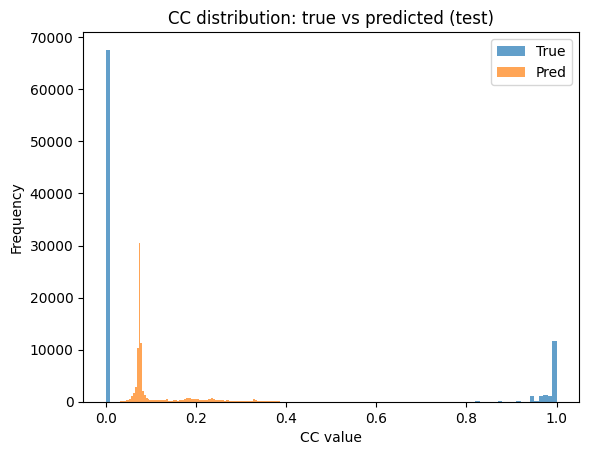

In [87]:
plt.figure()
plt.hist(true.ravel(), bins=100, alpha=0.7, label="True")
plt.hist(pred.ravel(), bins=100, alpha=0.7, label="Pred")
plt.title("CC distribution: true vs predicted (test)")
plt.xlabel("CC value")
plt.ylabel("Frequency")
plt.legend()
plt.show()


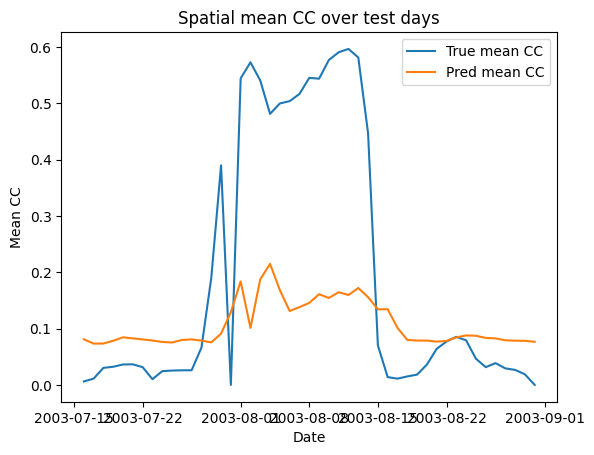

In [88]:
true_mean = true.mean(axis=(2,3)).squeeze()  # (N,)
pred_mean = pred.mean(axis=(2,3)).squeeze()

plt.figure()
plt.plot(test_dates, true_mean, label="True mean CC")
plt.plot(test_dates, pred_mean, label="Pred mean CC")
plt.title("Spatial mean CC over test days")
plt.xlabel("Date")
plt.ylabel("Mean CC")
plt.legend()
plt.show()

## Can the model learn network structure evolution?

Degree Centrality (DC)

How synchronized a region is with others.

➡ high = many regions experiencing heat together
➡ hubs of heatwave activity

Clustering Coefficient (CC)

Local clustering of heatwaves.

➡ high = localized heatwave cluster
➡ stationary behaviour

Betweenness Centrality (BC)

Propagation corridor importance.

➡ high = heatwave movement pathway
➡ dynamic propagation routes

Use CN metrics to:

✔ identify propagation corridors
✔ detect dynamic heatwaves
✔ validate DL trajectories

Use is_heatwave to:

✔ define events
✔ train models
✔ detect movement

Use E-OBS Tmax to:

✔ build sequences
✔ provide physical context